In [937]:
import torch
from torch import nn as nn
from torch import functional as F
import numpy as np
from matplotlib import pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.distributions import Normal
from tqdm import tqdm

In [767]:
f = lambda x : np.cos(np.pi/14*x) + np.sin(np.pi*x)

In [768]:
dataset = np.array([f(x)+0.5*np.random.randn() for x in np.arange(0, 100, 0.01)], dtype = np.float32)

In [769]:
N = len(dataset)
train_set = dataset[:int(0.8*N)]
test_set = dataset[int(0.8*N):]

In [896]:
class ts_dataset(Dataset):
    def __init__(self, dataset, lag = 128, horizon = 16):
        self.dataset = dataset
        self.lag = lag
        self.horizon = horizon
    def __len__(self):
        return len(self.dataset) - (self.lag+self.horizon) + 1
    def __getitem__(self, i):
        return self.dataset[i:i+self.lag], self.dataset[i+self.lag:i+self.lag+self.horizon]

In [897]:
train = ts_dataset(train_set)
test = ts_dataset(test_set)

In [898]:
train_t = DataLoader(train, batch_size = 1, shuffle = True, )
test_t = DataLoader(test, batch_size = 1, shuffle = False, )

In [899]:
x = torch.randn(2, 10,1)
h_0 = torch.zeros_like(torch.randn(1, 2, 3)).detach()
c_0 = torch.zeros_like(torch.randn(1, 2, 3)).detach()
nn.LSTM(1, 3, batch_first = True)(x, (h_0, c_0))

(tensor([[[-0.0781, -0.1104,  0.0270],
          [-0.0849, -0.1948, -0.0764],
          [-0.0727, -0.2465, -0.1833],
          [-0.0733, -0.2770, -0.2487],
          [-0.1566, -0.0747, -0.0481],
          [-0.1235, -0.1471, -0.0166],
          [-0.0505, -0.2031, -0.1460],
          [-0.0934, -0.2471, -0.2448],
          [-0.1259, -0.2184, -0.1428],
          [-0.1172, -0.2229, -0.0913]],
 
         [[-0.0547, -0.1393, -0.0922],
          [-0.1309, -0.0787,  0.0959],
          [-0.1216, -0.1400,  0.0668],
          [-0.1250, -0.1678,  0.0641],
          [-0.0747, -0.2273, -0.1281],
          [-0.1342, -0.1749, -0.0195],
          [-0.0552, -0.2215, -0.1561],
          [-0.0489, -0.2524, -0.2129],
          [-0.1138, -0.2399, -0.2634],
          [-0.0817, -0.2719, -0.2562]]], grad_fn=<TransposeBackward0>),
 (tensor([[[-0.1172, -0.2229, -0.0913],
           [-0.0817, -0.2719, -0.2562]]], grad_fn=<StackBackward0>),
  tensor([[[-0.3714, -0.4806, -0.1640],
           [-0.3693, -0.6102, -0.64

In [1014]:
class model(nn.Module):
    def __init__(self, intermediate_dim = 128, n_heads = 4):
        super().__init__()
        self.intermediate_dim = intermediate_dim
        self.lstm = nn.LSTM(1, intermediate_dim, batch_first = True)
        self.mu = nn.Linear(intermediate_dim,1)
        self.sigma = nn.Linear(intermediate_dim,1, )
    def forward(self, x):
        B, L, _ = x.shape
        h_0 = torch.zeros((1, B, self.intermediate_dim)).detach()
        c_0 = torch.zeros((1, B, self.intermediate_dim)).detach()
        states, (h,c) = self.lstm(x, (h_0, c_0))
        h_squeezed = h.squeeze(-2)
        return self.mu(h_squeezed), self.sigma(h_squeezed+2).exp()
   
@torch.no_grad
def take_shot(model, x):
    loc, scale = model(x)
    action = Normal(loc = loc, scale = scale).sample()
    return action         

In [1015]:
torch.manual_seed(5)
Model = model(512)

In [1016]:
optimizer = torch.optim.AdamW(Model.parameters(), lr=0.000001)
γ = 0.95

In [ ]:
for epoch in range(50):
    
    running_train_loss = 1e-2
    running_test_loss = 1e-2
    
    it = tqdm(enumerate(train_t))
    
    for i, (X,y) in it:
        Model.train()
        optimizer.zero_grad()
        
        loss = torch.tensor([0.0], dtype = torch.float32, requires_grad = True)
        reward = torch.tensor([0.0], dtype = torch.float32, requires_grad = False)
        
        pred_list = []
        weights = torch.tensor([γ**i for i in range(16)])
        for j, y_ in enumerate(y.tolist()[0]): ## Over a long horizon
            
            μ, σ = Model(X.unsqueeze(-1))

            dist =  Normal(loc = μ, scale = σ)
            
            pred_list.append(dist.sample()[0])
                        
            X = torch.roll(X, -1)
            
            X[0,-1] = pred_list[-1]
            
        actions_tensor = torch.tensor(pred_list) 
        rewards_tensor = -((actions_tensor - y)**2)*weights
        
        loss = -(dist.log_prob(actions_tensor)*rewards_tensor.sum()).mean()
        
        
        running_train_loss += (-rewards_tensor.mean().item()- running_train_loss)/(i+1)
        
        it.set_description(f"{running_train_loss}")
        
        loss.backward()
        optimizer.step()
        
        

1.9897136681314027: : 560it [00:35, 15.82it/s]

In [985]:
y_pred = []
y_test = []
for i, (X_, y_) in enumerate(test_t):
        with torch.inference_mode():
            if i < 900:
                y_pred_ = take_shot(Model, X_.unsqueeze(-1))
            else:
                y_pred_ = take_shot(Model,torch.tensor(y_pred[-128:]).unsqueeze(0).unsqueeze(-1))
            y_pred.append(y_pred_.item())
            y_test.append(y_[:, -1].item())
        if i > 1000:
            break
            

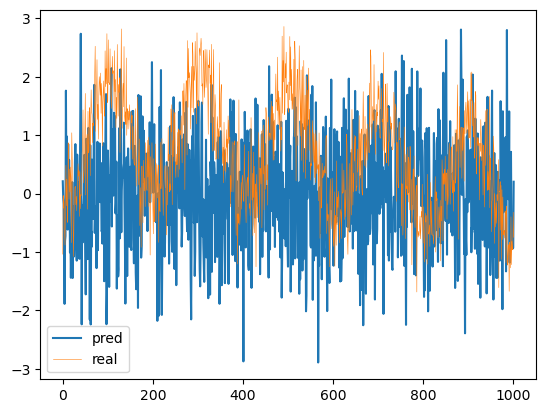

In [988]:
plt.plot(y_pred, label = "pred")
plt.plot(y_test, label = "real", linewidth=.4)
plt.legend()
plt.show()
### Domestic and National ChatGPT